# Imports

In [4]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', 500)
pd.options.plotting.backend = "plotly"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data

In [5]:
filepath = os.path.join("..","data","processed","validations_fusion.csv")
df = pd.read_csv(filepath)

In [6]:
df.head()

,jour,libelle_arret,id_zdc,categorie_titre,nb_vald,mois,jour_sem_num,nom_long,nom_so_gar,nom_su_gar,id_ref_zdc,nom_zdc,res_com,mode,train,rer,metro,tramway,val,tertrain,terrer,termetro,tertram,terval,exploitant,idf,principal,latitude,longitude
0,2025-03-07,MADELEINE,71324,Forfaits courts,3387,3,4,Madeleine,NaN,NaN,71324.0,Madeleine,METRO 8 / METRO 12 / METRO 14,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.870233,2.325164
1,2025-03-07,BARBES-ROCH.,71426,Autres titres,478,3,4,Barbès-Rochechouart,NaN,NaN,71426.0,Barbès Rochechouart,METRO 2 / METRO 4,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.883734,2.349525
2,2025-03-07,S. GAINSBOURG,490779,Contrat Solidarite Transport,781,3,4,Serge Gainsbourg,NaN,NaN,490779.0,Serge Gainsbourg,METRO 11,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.881316,2.427186
3,2025-03-07,S. GAINSBOURG,490779,Forfait Navigo,2880,3,4,Serge Gainsbourg,NaN,NaN,490779.0,Serge Gainsbourg,METRO 11,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.881316,2.427186
4,2025-03-07,S. GAINSBOURG,490779,Imagine R,1158,3,4,Serge Gainsbourg,NaN,NaN,490779.0,Serge Gainsbourg,METRO 11,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.881316,2.427186


In [7]:
df.shape

(1890468, 29)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1890468 entries, 0 to 1890467
Data columns (total 29 columns):
 #   Column           Dtype  
---  ------           -----  
 0   jour             object 
 1   libelle_arret    object 
 2   id_zdc           int64  
 3   categorie_titre  object 
 4   nb_vald          int64  
 5   mois             int64  
 6   jour_sem_num     int64  
 7   nom_long         object 
 8   nom_so_gar       object 
 9   nom_su_gar       object 
 10  id_ref_zdc       float64
 11  nom_zdc          object 
 12  res_com          object 
 13  mode             object 
 14  train            float64
 15  rer              float64
 16  metro            float64
 17  tramway          float64
 18  val              float64
 19  tertrain         float64
 20  terrer           float64
 21  termetro         float64
 22  tertram          float64
 23  terval           float64
 24  exploitant       object 
 25  idf              float64
 26  principal        float64
 27  latitude    

# Analyses.

## Validations par stations.

In [17]:
# Sélectionner nom station et nombre de validations.
stations_validations_df = df[["nom_zdc","nb_vald"]].copy()

# Grouper par station et somme des validations.
top_stations_df = stations_validations_df.groupby("nom_zdc")["nb_vald"].sum().reset_index()

# Tri pour avoir le top.
top_stations_df = top_stations_df.sort_values(by="nb_vald", ascending=False)

In [18]:
top_stations_df.head()

,nom_zdc,nb_vald
238,Gare Saint-Lazare,82580548
304,La Défense (Grande Arche),56568160
148,Châtelet,52722192
240,Gare de Lyon,48429105
237,Gare Montparnasse,42376168


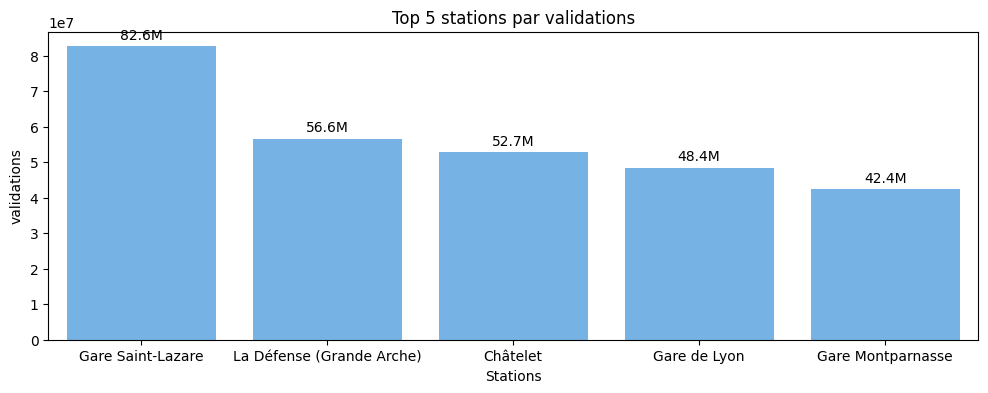

In [26]:
plt.figure(figsize=(12,4))

graph_stations = sns.barplot(top_stations_df.head(), x="nom_zdc", y="nb_vald", color="#64B5F6")

graph_stations.bar_label(
    graph_stations.containers[0],
    fmt=lambda x: f"{x*1e-6:.1f}M",
    padding=3
)

plt.title("Top 5 stations par validations")
plt.xlabel("Stations")
plt.ylabel("validations")

plt.show()

## Validations par lignes.

In [28]:
# Somme "nb_vald" pour une ligne donnée.
df[df["res_com"].str.contains("RER B", na=False)]["nb_vald"].sum()

np.int64(190203361)

In [29]:
# Lire csv de validations par ligne.
lignes_filepath = os.path.join("..","data","processed","validations_ligne.csv")
lignes_df = pd.read_csv(lignes_filepath)

In [30]:
lignes_df.head()

,Ligne,somme_nb_vald
0,RER A,324994656
1,RER B,190203361
2,RER C,180974086
3,RER D,191192832
4,RER E,201652557


In [ ]:
# PLOTLY
#fig = px.histogram(lignes_df, x="Ligne", y="somme_nb_vald",)
#fig.update_traces(marker_color='#64B5F6')
#fig

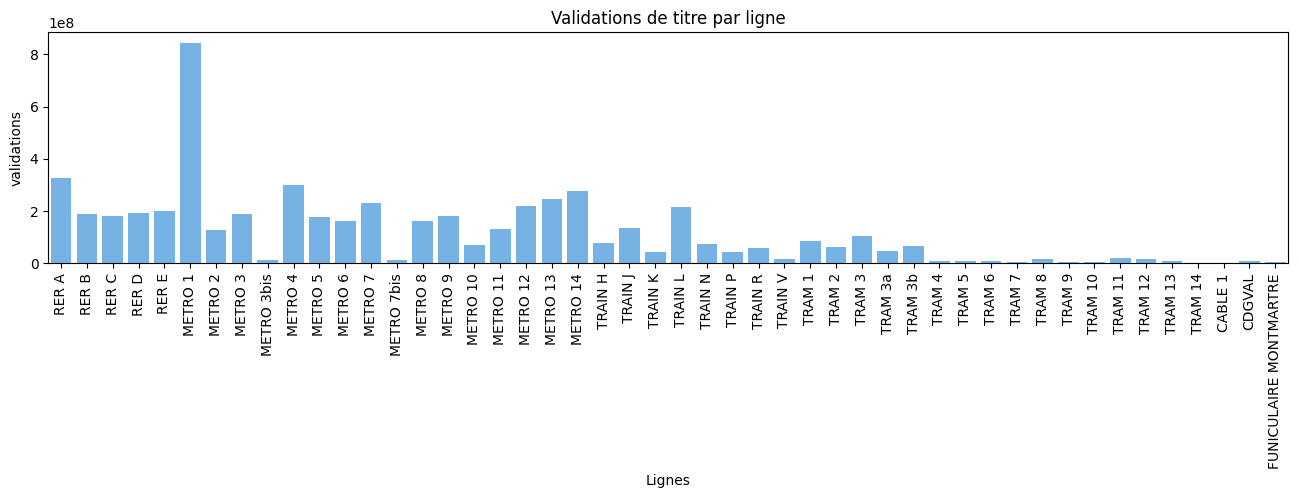

In [32]:
# Validations de titre par ligne.

plt.figure(figsize=(16,3))

sns.barplot(lignes_df, x="Ligne", y="somme_nb_vald", color="#64B5F6")

plt.xticks(rotation="vertical")
plt.title("Validations de titre par ligne")
plt.xlabel("Lignes")
plt.ylabel("validations")

plt.show()

In [38]:
# Top lignes.
top_lignes_df = lignes_df.sort_values(by="somme_nb_vald", ascending=False).head()
top_lignes_df

,Ligne,somme_nb_vald
5,METRO 1,842868704
0,RER A,324994656
9,METRO 4,301538185
20,METRO 14,278501830
19,METRO 13,245353261


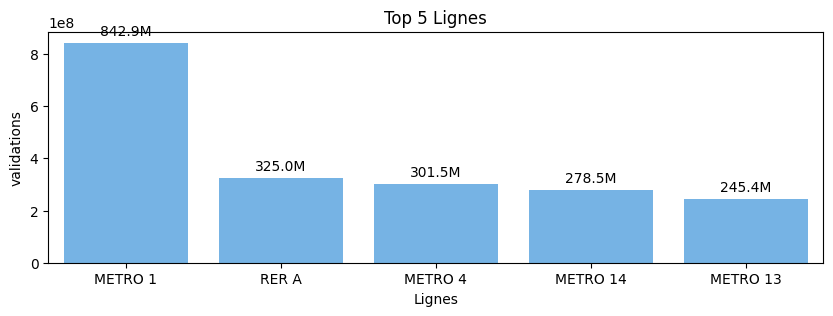

In [36]:
# Top lignes graphique.

plt.figure(figsize=(10,3))

graph_ligne = sns.barplot(top_lignes_df, x="Ligne", y="somme_nb_vald", color="#64B5F6")

graph_ligne.bar_label(
    graph_ligne.containers[0],
    fmt=lambda x: f"{x*1e-6:.1f}M",
    padding=3
)

plt.title("Top 5 Lignes")
plt.xlabel("Lignes")
plt.ylabel("validations")

plt.show()

## Scatterplot